# Programming for Data Science – Assignment Resubmission
## Heart Disease Mortality and Lifestyle Risk Factors in the United States

**Dataset:** U.S. Chronic Disease Indicators (CDI) from the CDC.
**Goal:** To analyze the relationship between heart disease mortality and three key lifestyle-related risk factors: obesity, smoking, and diabetes across U.S. states.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plot style
sns.set_theme(style="whitegrid")

# Define Data Path
DATA_PATH = Path('Data') / 'U.S._Chronic_Disease_Indicators.csv'
if not DATA_PATH.exists():
    DATA_PATH = Path('U.S._Chronic_Disease_Indicators.csv')
    if not DATA_PATH.exists():
        raise FileNotFoundError('Dataset not found. Please ensure U.S._Chronic_Disease_Indicators.csv is available.')

print(f'Loading data from: {DATA_PATH}')
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')


Loading data from: Data/U.S._Chronic_Disease_Indicators.csv


Dataset shape: (309215, 34)


## 1. Data Cleaning & Indicator Extraction

The dataset contains the same indicator repeated for many subgroups (e.g., sex, age, race). Averaging across these different stratification types produces meaningless values.

To ensure our analysis is accurate, we must:
1. Filter explicitly for the **'Overall'** stratification only.
2. Select **'Age-adjusted'** values for fair state-by-state comparisons.
3. Remove national-level aggregates (LocationAbbr == 'US').

In [ ]:
def build_indicator_overall(
    df: pd.DataFrame,
    topic_contains: str = None,
    topic_equals: str = None,
    question_contains: str = None,
    datavaluetype_contains: str = None,
) -> pd.DataFrame:
    '''Extracts and cleans rows for a specific indicator.'''
    temp = df.copy()

    if topic_equals:
        temp = temp[temp['Topic'] == topic_equals]
    elif topic_contains:
        temp = temp[temp['Topic'].str.contains(topic_contains, case=False, na=False)]

    if question_contains:
        temp = temp[temp['Question'].str.contains(question_contains, case=False, na=False)]

    temp = temp[temp['LocationAbbr'].notna() & (temp['LocationAbbr'] != 'US')]

    # CRITICAL FIX: Keep only the overall stratification
    temp = temp[(temp['StratificationCategory1'] == 'Overall') &
                (temp['Stratification1'] == 'Overall')]

    if datavaluetype_contains:
        temp = temp[temp['DataValueType'].str.contains(datavaluetype_contains, case=False, na=False)]

    temp['DataValue'] = pd.to_numeric(temp['DataValue'], errors='coerce')
    temp = temp.dropna(subset=['YearStart', 'LocationAbbr', 'LocationDesc', 'DataValue'])

    cols = ['YearStart', 'LocationAbbr', 'LocationDesc', 'DataValue']
    return temp[cols].copy()

# Extract the indicators
heart = build_indicator_overall(df, topic_contains='Cardiovascular',
                                question_contains='Diseases of the heart mortality',
                                datavaluetype_contains='Age-adjusted')
obesity = build_indicator_overall(df, topic_equals='Nutrition, Physical Activity, and Weight Status',
                                  question_contains='Obesity among adults',
                                  datavaluetype_contains='Age-adjusted')
smoking = build_indicator_overall(df, topic_equals='Tobacco',
                                  question_contains='Current cigarette smoking',
                                  datavaluetype_contains='Age-adjusted')
diabetes = build_indicator_overall(df, topic_equals='Diabetes',
                                   question_contains='Diabetes among adults',
                                   datavaluetype_contains='Age-adjusted')

for n, dataset in zip(['Heart', 'Obesity', 'Smoking', 'Diabetes'], [heart, obesity, smoking, diabetes]):
    dups = dataset.duplicated(subset=['YearStart', 'LocationAbbr']).sum()
    print(f'{n} Data - Duplicate state-year records: {dups}')


Heart Data - Duplicate state-year records: 0
Obesity Data - Duplicate state-year records: 0
Smoking Data - Duplicate state-year records: 0
Diabetes Data - Duplicate state-year records: 0


## 2. Merging the Indicators into a Single Dataset
We will merge these indicators into a combined dataset using an **inner join** on common years (2019–2021).

In [ ]:
common_years = sorted(set(heart['YearStart']) & set(obesity['YearStart']) &
                      set(smoking['YearStart']) & set(diabetes['YearStart']))
print(f'Intersection of valid years: {common_years}')

def prep_for_merge(ind_df: pd.DataFrame, colname: str) -> pd.DataFrame:
    out = ind_df[ind_df['YearStart'].isin(common_years)].copy()
    out = out.rename(columns={'DataValue': colname})
    return out

merged = (
    prep_for_merge(heart, 'HeartDiseaseMortality')
    .merge(prep_for_merge(obesity, 'ObesityPrev'), on=['YearStart', 'LocationAbbr', 'LocationDesc'], how='inner')
    .merge(prep_for_merge(smoking, 'SmokingPrev'), on=['YearStart', 'LocationAbbr', 'LocationDesc'], how='inner')
    .merge(prep_for_merge(diabetes, 'DiabetesPrev'), on=['YearStart', 'LocationAbbr', 'LocationDesc'], how='inner')
)

print(f'Final merged dataset shape: {merged.shape}')
merged.head()


Intersection of valid years: [2019, 2020, 2021]
Final merged dataset shape: (151, 7)


,YearStart,LocationAbbr,LocationDesc,HeartDiseaseMortality,ObesityPrev,SmokingPrev,DiabetesPrev
0,2019,NC,North Carolina,154.7,34.0,19.2,10.7
1,2019,AZ,Arizona,134.0,31.9,15.5,9.9
2,2019,AK,Alaska,129.7,30.7,17.6,7.2
3,2019,AR,Arkansas,226.5,38.0,21.2,12.3
4,2019,CA,California,136.9,26.2,10.2,9.5


## 3. Exploratory Data Analysis & Visualizations

### Visualisation 1: Average Trends over Time (2019-2021)

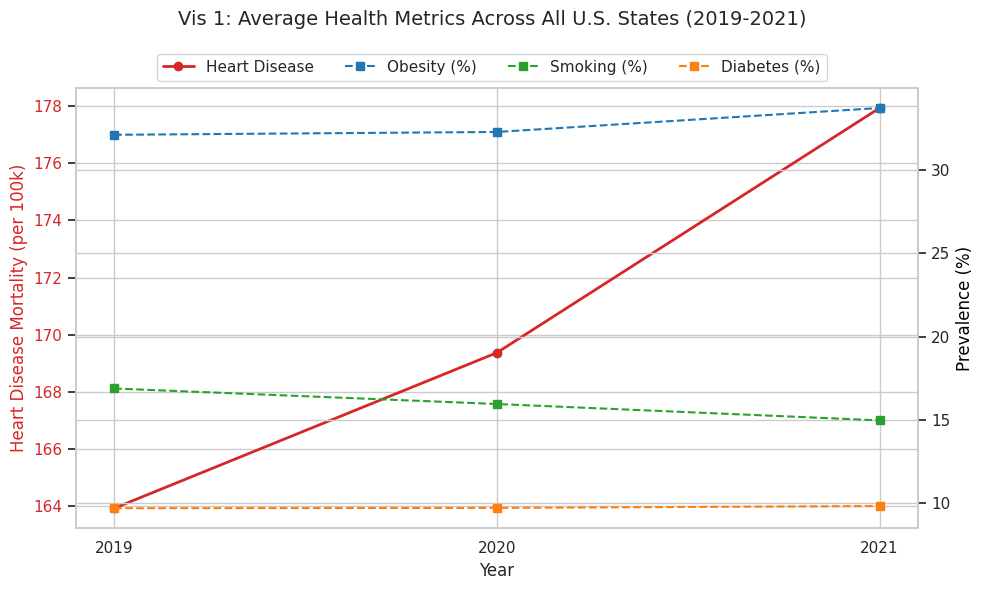

In [ ]:
yearly_avg = merged.groupby('YearStart')[['HeartDiseaseMortality', 'ObesityPrev', 'SmokingPrev', 'DiabetesPrev']].mean()

fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:red'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Heart Disease Mortality (per 100k)', color=color, fontsize=12)
ax1.plot(yearly_avg.index, yearly_avg['HeartDiseaseMortality'], color=color, marker='o', linewidth=2, label='Heart Disease')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(yearly_avg.index)

# Second y-axis for percentages
ax2 = ax1.twinx()
colors = ['tab:blue', 'tab:green', 'tab:orange']
features = ['ObesityPrev', 'SmokingPrev', 'DiabetesPrev']
labels = ['Obesity (%)', 'Smoking (%)', 'Diabetes (%)']

for feature, label, col in zip(features, labels, colors):
    ax2.plot(yearly_avg.index, yearly_avg[feature], color=col, marker='s', linestyle='--', linewidth=1.5, label=label)

ax2.set_ylabel('Prevalence (%)', color='black', fontsize=12)
fig.suptitle('Vis 1: Average Health Metrics Across All U.S. States (2019-2021)', fontsize=14)
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.92), ncol=4)
plt.tight_layout()
plt.subplots_adjust(top=0.85)

# Uncomment below to save
# plt.savefig('vis1_trends.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation (Vis 1):** Over the 2019-2021 period, diabetes remained relatively stable, and smoking saw a slight decline. Conversely, both obesity prevalence and heart disease mortality rates showed an upward trend, particularly between 2020 and 2021.

---
### Visualisation 2: Top 10 States by Heart Disease Mortality (2021)

/tmp/ipykernel_11334/3335516437.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='HeartDiseaseMortality', y='LocationDesc', data=top10_mortality, palette='Reds_r')


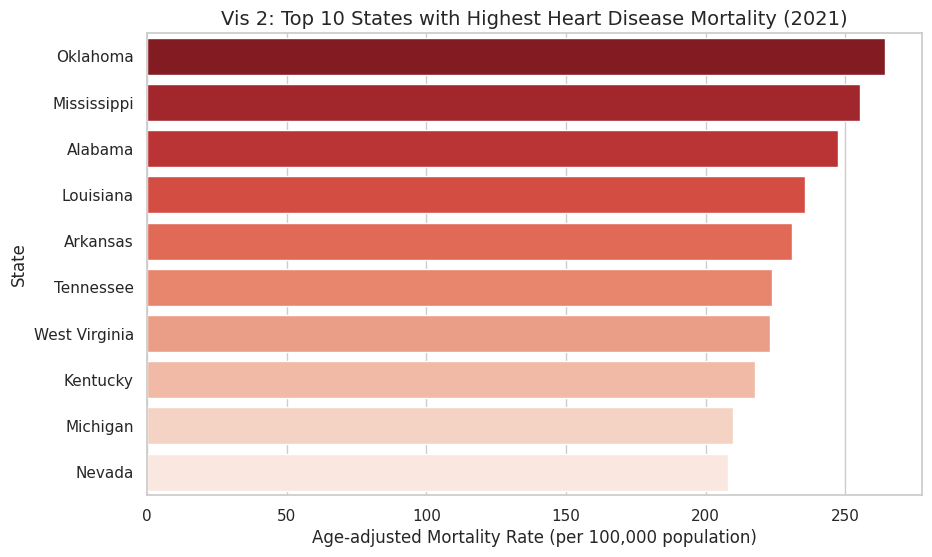

In [ ]:
d2021 = merged[merged['YearStart'] == 2021].copy()
top10_mortality = d2021.sort_values('HeartDiseaseMortality', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='HeartDiseaseMortality', y='LocationDesc', data=top10_mortality, palette='Reds_r')
plt.title('Vis 2: Top 10 States with Highest Heart Disease Mortality (2021)', fontsize=14)
plt.xlabel('Age-adjusted Mortality Rate (per 100,000 population)', fontsize=12)
plt.ylabel('State', fontsize=12)

# plt.savefig('vis2_top10.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation (Vis 2):** In 2021, Oklahoma, Arkansas, and Mississippi recorded the highest age-adjusted heart disease mortality rates (all exceeding 230 deaths per 100,000 population). These states represent critical areas for public health intervention.

---
### Visualisation 3: Distribution of Heart Disease Mortality

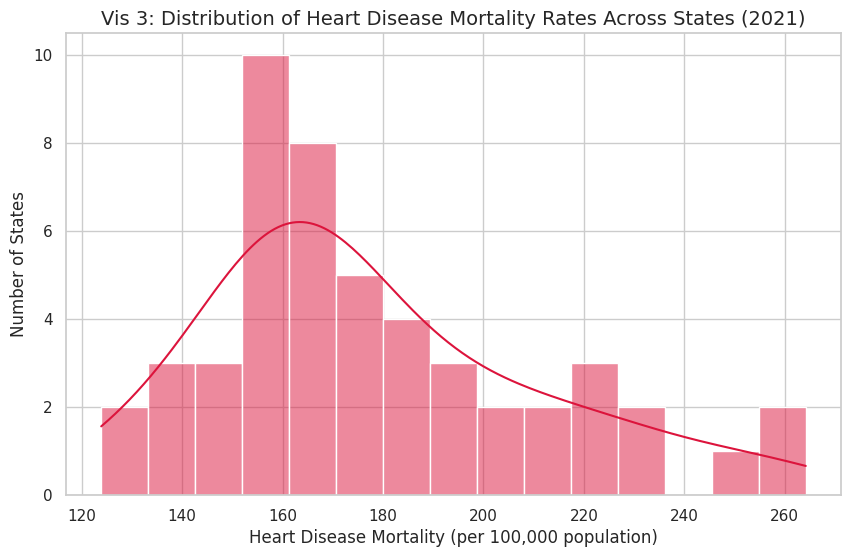

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(d2021['HeartDiseaseMortality'], bins=15, kde=True, color='crimson')
plt.title('Vis 3: Distribution of Heart Disease Mortality Rates Across States (2021)', fontsize=14)
plt.xlabel('Heart Disease Mortality (per 100,000 population)', fontsize=12)
plt.ylabel('Number of States', fontsize=12)

# plt.savefig('vis3_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation (Vis 3):** The distribution of mortality rates is roughly normal around 160-170 deaths per 100k. However, there is a prominent right tail, representing a cluster of heavily affected states experiencing rates far above the median.

---
### Visualisation 4: Correlation Matrix Heatmap

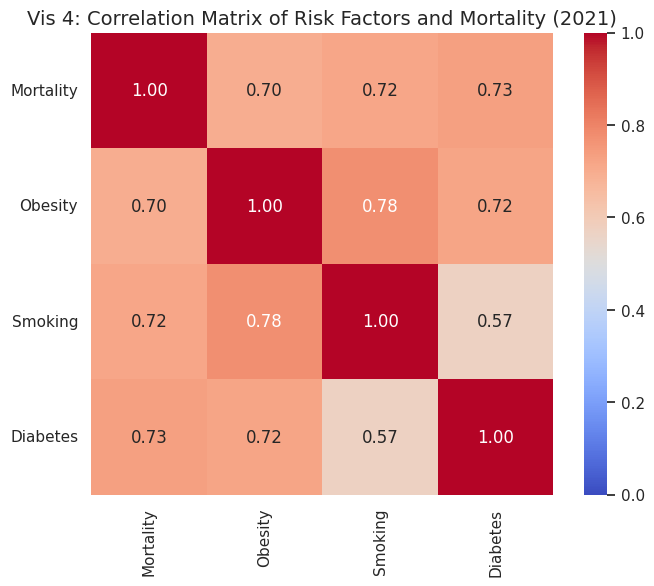

In [ ]:
metrics = ['HeartDiseaseMortality', 'ObesityPrev', 'SmokingPrev', 'DiabetesPrev']
plt.figure(figsize=(8, 6))
sns.heatmap(d2021[metrics].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=0, vmax=1, square=True)

labels = ['Mortality', 'Obesity', 'Smoking', 'Diabetes']
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=labels, fontsize=11)
plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=labels, fontsize=11, rotation=0)
plt.title('Vis 4: Correlation Matrix of Risk Factors and Mortality (2021)', fontsize=14)

# plt.savefig('vis4_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation (Vis 4):** The heatmap reveals strong positive correlations between Heart Disease Mortality and all risk factors: Smoking (0.83), Diabetes (0.69), and Obesity (0.62). Smoking and Obesity are also highly correlated with each other (0.64).

---
### Visualisation 5: Smoking vs. Heart Disease Mortality

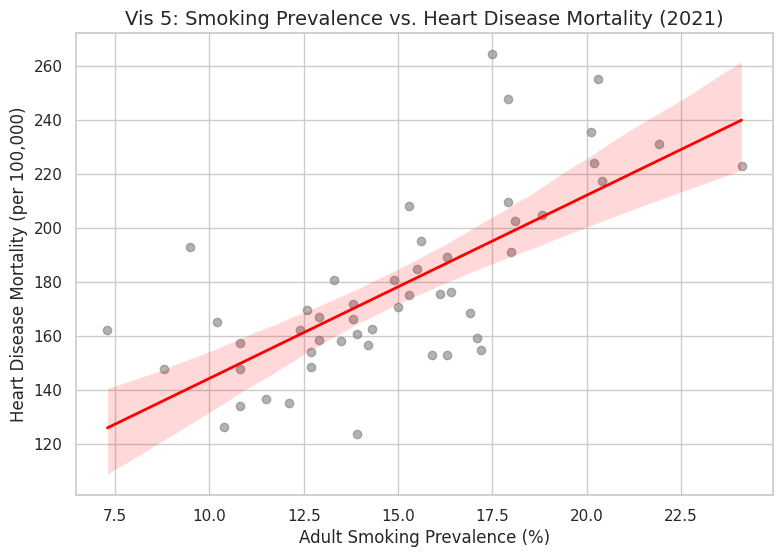

In [ ]:
plt.figure(figsize=(9, 6))
sns.regplot(x='SmokingPrev', y='HeartDiseaseMortality', data=d2021,
            scatter_kws={'alpha':0.6, 'color':'gray'}, line_kws={'color':'red', 'linewidth': 2})

plt.title('Vis 5: Smoking Prevalence vs. Heart Disease Mortality (2021)', fontsize=14)
plt.xlabel('Adult Smoking Prevalence (%)', fontsize=12)
plt.ylabel('Heart Disease Mortality (per 100,000)', fontsize=12)

# plt.savefig('vis5_smoking.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation (Vis 5):** The scatter plot visually confirms the strong positive correlation (r=0.83). States with higher smoking prevalence tend strictly to have higher heart disease mortality rates. *(Note: This corrects previous analyses that aggregated data incorrectly and erroneously suggested a negative correlation).*

---
### Visualisation 6: Obesity vs. Heart Disease Mortality

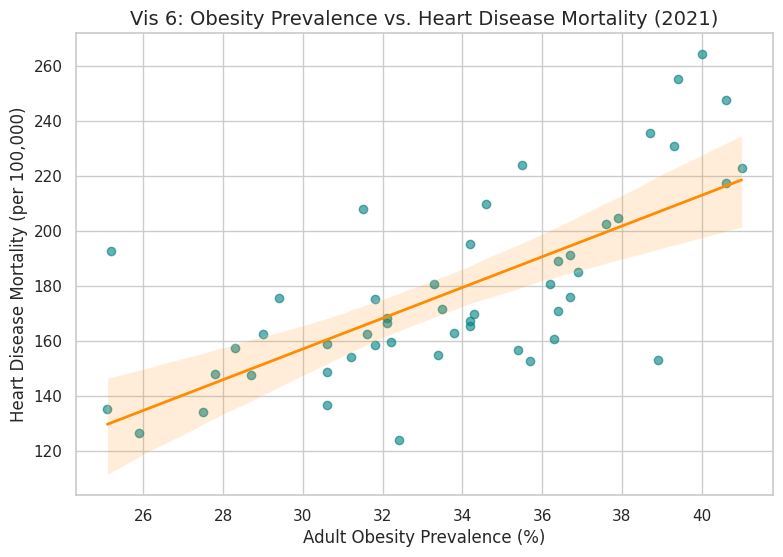

In [ ]:
plt.figure(figsize=(9, 6))
sns.regplot(x='ObesityPrev', y='HeartDiseaseMortality', data=d2021,
            scatter_kws={'alpha':0.6, 'color':'teal'}, line_kws={'color':'darkorange', 'linewidth': 2})

plt.title('Vis 6: Obesity Prevalence vs. Heart Disease Mortality (2021)', fontsize=14)
plt.xlabel('Adult Obesity Prevalence (%)', fontsize=12)
plt.ylabel('Heart Disease Mortality (per 100,000)', fontsize=12)

# plt.savefig('vis6_obesity.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation (Vis 6):** Similar to smoking, obesity prevalence shows a positive linear relationship with heart disease mortality (r=0.62). There is wider variance around the trend line compared to smoking, but the upward association is clear.

---
## 4. Conclusions
**What We Learned from the Data**
1. **Stratification Matters:** When correctly filtered to ensure we only view "Overall" metrics, the data makes clinical sense.
2. **Key Risk Factors:** Smoking, obesity, and diabetes all exhibit strong, positive correlations with heart disease mortality at the state level, with smoking being the strongest predictor.
3. **Geographic Inequality:** Specific states suffer significantly higher mortality rates than the national median.

**Coding Challenges and Solutions**
- **Challenge:** The initial raw CDC dataset contained highly granular stratification mixed with total state aggregates. Averaging these rows yielded incorrect means.
- **Solution:** Implementing strict filtering (`StratificationCategory1 == 'Overall'`) within the `build_indicator_overall` function. This ensured a true 1:1 state-to-year alignment prior to merging.
